# Trading Costs and Liquidity

We have taken prices as given and discussed quantitative allocation rules that outperform relative to a CAPM benchmark. An important question is whether we could actually trade at those prices when implementing the strategy.

This notebook explores:
1. What makes a security liquid or illiquid
2. How to measure the implementability of a trading strategy
3. How to build implementation-friendly portfolios that track a desired strategy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.tseries.offsets import MonthEnd

%matplotlib inline

## What Is Liquidity?

**Liquidity** is the ease of trading a security. Several forces impose costs on those wishing to trade:

1. **Exogenous transaction costs:** brokerage fees, order-processing costs, transaction taxes.
2. **Demand pressure:** when you need to sell quickly and no natural buyer is available, whoever steps in will demand compensation.
3. **Inventory risk:** a market maker who absorbs your position faces future price risk and charges for it.
4. **Private information:** counterparties worry about trading against someone with superior information (about fundamentals or future flows) and price-protect accordingly.

Measuring trading costs precisely requires costly experimentation — actually trading and observing how prices move in response.

## Implementation Shortfall

- **Wish portfolio:** the portfolio you would hold if trading were costless.
- **Performance of wish portfolio:** returns computed in real time at mid prices.

$$\text{Shortfall} = R^{\text{wish}} - R^{\text{actual}}$$

Shortfall has two components:
- **Execution costs:** the direct cost of trading toward the wish portfolio.
- **Opportunity costs:** the cost of *deviating* from the wish portfolio (because trading toward it is too expensive).

**The key trade-off:** trading quickly reduces opportunity cost but increases execution cost (market impact). Trading slowly does the opposite.

The optimal policy:
1. Find a tracking-error cap that minimizes total shortfall.
2. If current tracking error is below the cap, don't trade.
3. When tracking error threatens to exceed the cap, trade just enough to bring it back.

The cost of trading depends heavily on *who* is trading — specifically, on position size relative to available liquidity.

## Absorption Capacity

A practical way to gauge implementability: measure how much of each stock's trading volume your strategy would consume.

$$\text{UsedVolume}_{i,t} = \frac{\text{Trading}_{i,t}}{\text{Volume}_{i,t}}$$

If you trade a small fraction of volume, you can likely transact near posted prices. As that fraction grows, market impact rises steeply.

The figure below shows realized trading costs for trades made by AQR as a function of trade size relative to volume:

![Market Impact](../../assets/plots/marketimpact.jpg)

## How Much Do You Actually Need to Trade?

Compare the desired weight at $t+1$ with the weight you *already hold* after returns are realized:

$$w_{i,t+1}(\text{before trading}) = \frac{w_{i,t}^* \cdot (1 + r_{i,t+1})}{1 + r_{t+1}^{\text{strategy}}}$$

The required trade, scaled by volume:

$$\text{UsedVolume}_{i,t} = \frac{\text{Position}}{\text{Volume}_{i,t}} \left( w_{i,t+1}^* - \frac{w_{i,t}^* (1 + r_{i,t+1})}{1 + r_{t+1}^{\text{strategy}}} \right)$$

**Interpreting this statistic:**
- If $\text{UsedVolume}_{i,t} \approx 1$ for some stock, your strategy would consume nearly *all* of that stock's volume — prices will move against you.
- The **maximum** across stocks is the "weakest link" — the hardest stock to trade in your portfolio.
- Looking at the 95th/75th/50th percentiles tells you whether dropping the least liquid 5–25% of stocks might substantially reduce costs.

> Can we change the portfolios to reduce trading costs without significantly altering their return properties?

In [2]:
# Load monthly CRSP data
crsp = pd.read_pickle(
    'https://raw.githubusercontent.com/amoreira2/Lectures/main/assets/data/crspm2005_2020.pkl'
)

crsp['permno'] = crsp['permno'].astype(int)
crsp['date'] = crsp['date'] + MonthEnd(0)
crsp['me'] = crsp['prc'].abs() * crsp['shrout']  # market equity

crsp = (crsp[['permno', 'date', 'ret', 'me', 'vol', 'prc']]
        .sort_values(['permno', 'date'])
        .drop_duplicates())

crsp.head()

,permno,date,ret,me,vol,prc
1,10001,2005-01-31,-0.040580,17178.899703,515.0,6.620
4567,10001,2005-02-28,-0.045166,16428.279258,726.0,6.321
9580,10001,2005-03-31,0.124822,18663.750350,4107.0,7.110
14333,10001,2005-04-30,-0.074684,17269.874990,527.0,6.579
18979,10001,2005-05-31,0.219030,21052.501202,1990.0,8.020


In [3]:
def compute_momentum_signal(data):
    """Compute 12-month cumulative return, skipping the most recent month."""
    tmp = data[['permno', 'date', 'ret', 'me', 'vol', 'prc']].copy()
    tmp = tmp.sort_values(['permno', 'date'])
    tmp['volume'] = tmp['vol'] * tmp['prc'].abs() * 100 / 1e6  # dollar volume in $M

    # 12-month cumulative return
    tmp['grossret'] = tmp['ret'] + 1
    tmp['cumret'] = tmp.groupby('permno')['grossret'].transform(
        lambda x: x.rolling(window=12).apply(np.prod, raw=True) - 1
    )
    # Skip most recent month (standard momentum convention)
    tmp['mom'] = tmp.groupby('permno')['cumret'].shift(2)

    # Rank into deciles each month
    tmp = tmp.dropna(subset=['mom']).sort_values(['date', 'permno'])
    tmp['mom_group'] = (tmp.groupby('date')['mom']
                        .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')))
    tmp = tmp.dropna(subset=['mom_group'])
    tmp['mom_group'] = 'm' + tmp['mom_group'].astype(int).astype(str)
    tmp['date'] = tmp['date'] + MonthEnd(0)
    return tmp.sort_values(['permno', 'date'])


def build_portfolios(tmp, wghtvar='me'):
    """Build value- or volume-weighted portfolios from momentum-ranked data."""
    # Portfolio weights
    tmp = tmp.copy()
    tmp['Wght'] = tmp.groupby(['date', 'mom_group'])[wghtvar].transform(lambda x: x / x.sum())

    # Weighted returns
    tmp['wret'] = tmp['Wght'] * tmp['ret']
    port_ret = tmp.groupby(['date', 'mom_group'])['wret'].sum().reset_index()
    port_ret = port_ret.rename(columns={'wret': 'port_ret'})

    # Merge portfolio return back for trade computations
    tmp = tmp.merge(port_ret, on=['date', 'mom_group'], how='left')

    # Lead weights and group membership
    tmp = tmp.sort_values(['permno', 'date'])
    tmp['Wght_lead'] = tmp.groupby('permno')['Wght'].shift(-1)
    tmp['mom_group_lead'] = tmp.groupby('permno')['mom_group'].shift(-1)

    # Pivot to wide format
    port_wide = port_ret.set_index(['date', 'mom_group']).unstack()['port_ret']

    return port_wide, tmp

In [4]:
# Build value-weighted momentum portfolios (with stock-level weights for trade analysis)
tmp = compute_momentum_signal(crsp)
port_ret, wght = build_portfolios(tmp, wghtvar='me')
wght.head()

,permno,date,ret,me,vol,prc,volume,grossret,cumret,mom,mom_group,Wght,wret,port_ret,Wght_lead,mom_group_lead
0,10001,2006-02-28,-0.010537,27522.091006,439.0,9.390,0.412221,0.989463,0.499266,0.411365,m8,0.000016,-1.677740e-07,-0.003999,0.000024,m8
1,10001,2006-03-31,0.170394,32222.679329,777.0,10.990,0.853923,1.170394,0.560008,0.446795,m8,0.000024,4.068272e-06,0.032930,0.000020,m8
2,10001,2006-04-30,-0.094631,29173.399441,883.0,9.950,0.878585,0.905369,0.526377,0.499266,m8,0.000020,-1.888186e-06,0.018943,0.000024,m8
3,10001,2006-05-31,-0.010452,28633.911396,319.0,9.766,0.311535,0.989548,0.239037,0.560008,m8,0.000024,-2.530443e-07,-0.046612,0.000023,m7
4,10001,2006-06-30,-0.076387,26464.681343,1186.0,9.020,1.069772,0.923613,0.014145,0.526377,m7,0.000023,-1.733819e-06,0.001877,0.000017,m6


In [5]:
# Required trade for each stock: difference between desired weight next period
# and what you'd hold if you didn't rebalance
mom = wght.copy()

# Rebalancing trade (stocks staying in same decile)
mom['trade'] = (mom['Wght_lead'] * (mom['mom_group'] == mom['mom_group_lead'])
                - mom['Wght'] * (1 + mom['ret']) / (1 + mom['port_ret']))

# New-buy trade (stocks switching deciles)
mom['trade_newbuys'] = (~(mom['mom_group'] == mom['mom_group_lead'])) * mom['Wght_lead']

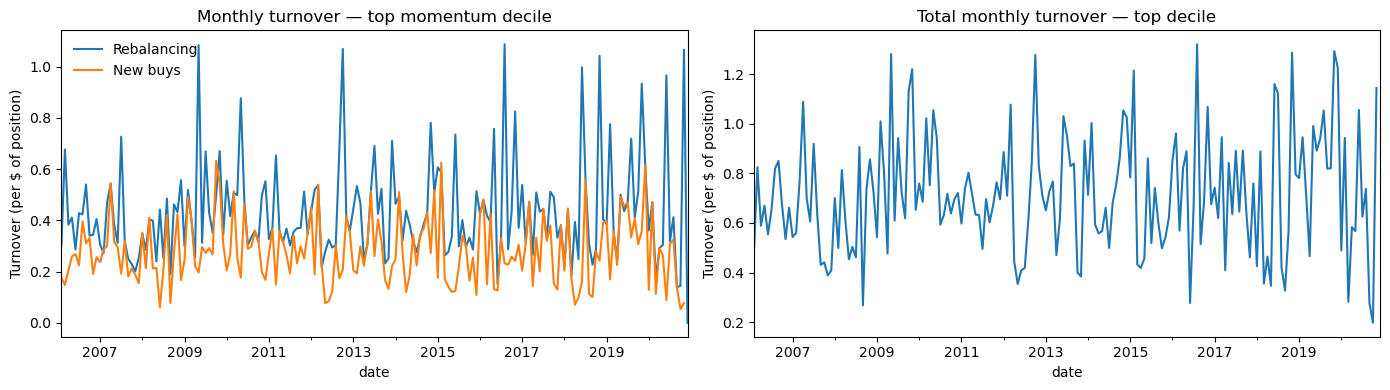

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Per-dollar turnover for top decile
ax = axes[0]
(mom.groupby(['date', 'mom_group'])['trade']
 .apply(lambda x: x.abs().sum()).loc[:, 'm9']).plot(ax=ax, label='Rebalancing')
(mom.groupby(['date', 'mom_group_lead'])['trade_newbuys']
 .apply(lambda x: x.abs().sum()).loc[:, 'm9']).plot(ax=ax, label='New buys')
ax.set_title('Monthly turnover — top momentum decile')
ax.set_ylabel('Turnover (per $ of position)')
ax.legend(frameon=False)

# Total turnover
ax = axes[1]
total = (mom.groupby(['date', 'mom_group'])['trade']
         .apply(lambda x: x.abs().sum()).loc[:, 'm9']
         + mom.groupby(['date', 'mom_group_lead'])['trade_newbuys']
         .apply(lambda x: x.abs().sum()).loc[:, 'm9'])
total.plot(ax=ax)
ax.set_title('Total monthly turnover — top decile')
ax.set_ylabel('Turnover (per $ of position)')

plt.tight_layout()
plt.show()

In [7]:
# Normalize trade by dollar volume
mom['trade_per_vol'] = mom['trade'] / mom['volume']
mom['newbuys_per_vol'] = mom['trade_newbuys'] / mom['volume']

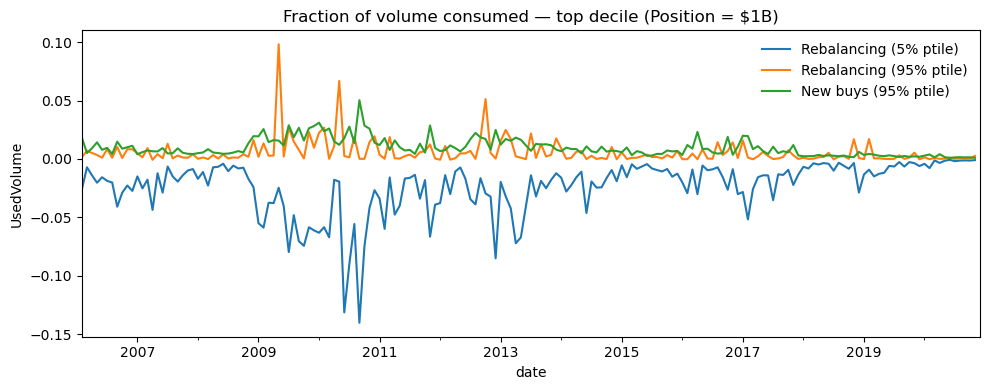

In [8]:
# How much volume would a $1B position consume at the tails?
Position = 1e3  # $1B (units are $M)
threshold = 0.05

fig, ax = plt.subplots(figsize=(10, 4))
(Position * mom.groupby(['date', 'mom_group'])['trade_per_vol']
 .quantile(threshold).loc[:, 'm9']).plot(ax=ax, label=f'Rebalancing ({threshold:.0%} ptile)')
(Position * mom.groupby(['date', 'mom_group'])['trade_per_vol']
 .quantile(1 - threshold).loc[:, 'm9']).plot(ax=ax, label=f'Rebalancing ({1-threshold:.0%} ptile)')
(Position * mom.groupby(['date', 'mom_group'])['newbuys_per_vol']
 .quantile(1 - threshold).loc[:, 'm9']).plot(ax=ax, label=f'New buys ({1-threshold:.0%} ptile)')

ax.set_title(f'Fraction of volume consumed — top decile (Position = ${Position/1e3:.0f}B)')
ax.set_ylabel('UsedVolume')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Tracking Error

Let $W^{\text{wish}}_t$ and $W^{\text{impl}}_t$ denote the wish and implementation portfolio weights. Run the regression:

$$W^{\text{impl}}_t R_{t+1} = \alpha + \beta \, W^{\text{wish}}_t R_{t+1} + \varepsilon_{t+1}$$

A good implementation portfolio has:
- $\beta \approx 1$ (same systematic exposure)
- $\sigma(\varepsilon) \approx 0$ (low idiosyncratic tracking error)
- $\alpha \approx 0$ (no expected cost of deviating)

**$\beta \neq 1$** is the easiest to fix — just lever up or down.

**$\sigma(\varepsilon)$** can only be reduced by making the implementation portfolio more similar to the wish portfolio.

**$\alpha < 0$** is the true cost — the expected return you sacrifice by deviating.

---

*Industry convention* often collapses tracking error to a single number: $\sigma(R^{\text{impl}} - R^{\text{wish}})$. This mixes the $\beta$ and $\varepsilon$ components and ignores $\alpha$ entirely.

The implementation portfolio is chosen by trading off market impact (execution cost) and tracking error (opportunity cost). One can construct strategies that avoid the least liquid stocks and examine how much tracking error increases — and whether that increase is worth the reduction in trading costs.

## Constructing an Implementation Portfolio

A simple approach: **weight by trading volume** instead of market cap.

This ensures you use roughly the same fraction of volume across all positions — avoiding concentration in illiquid names.

A more sophisticated approach: exclude stocks that are currently illiquid or likely to become illiquid next period. This amounts to interacting the momentum signal with a liquidity signal.

Let's compare the two approaches: value-weighted (wish portfolio) vs. volume-weighted (implementation portfolio).

In [9]:
# Value-weighted (wish portfolio)
port_me, _ = build_portfolios(tmp, wghtvar='me')

# Volume-weighted (implementation portfolio)
port_vol, _ = build_portfolios(tmp, wghtvar='volume')

# Combine top-decile returns
momportfolios = port_me.merge(port_vol, left_index=True, right_index=True, suffixes=['_me', '_vol'])

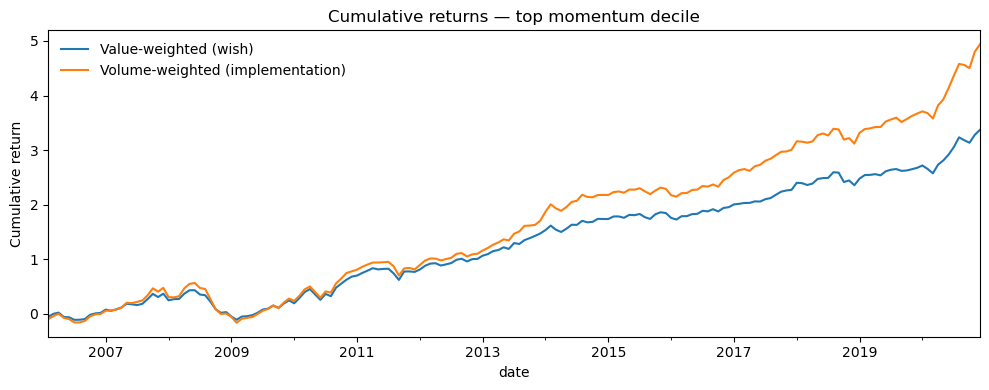

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
momportfolios[['m9_me', 'm9_vol']].cumsum().plot(ax=ax)
ax.set_title('Cumulative returns — top momentum decile')
ax.set_ylabel('Cumulative return')
ax.legend(['Value-weighted (wish)', 'Volume-weighted (implementation)'], frameon=False)
plt.tight_layout()
plt.show()

**Don't be fooled by the long-only performance** — replicating the market is easy. The real question is how well the implementation portfolio tracks the *wish* portfolio, especially for the long-short spread.

In [11]:
# Regress implementation returns on wish-portfolio returns
y = momportfolios['m9_vol']
X = sm.add_constant(momportfolios['m9_me'])
results = sm.OLS(y, X).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 m9_vol   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     1721.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           4.18e-93
Time:                        10:28:22   Log-Likelihood:                 416.06
No. Observations:                 179   AIC:                            -828.1
Df Residuals:                     177   BIC:                            -821.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0044      0.002      2.341      0.020       0.001       0.008
m9_me          1.2327      0.030     41.481      0.000       1.174       1.291
==============================================================================
Omnibus:                       44.660   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              123.226
Skew:                           1.018   Prob(JB):                     1.74e-27
Kurtosis:                       6.518   Cond. No.                         16.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations:**

- The $\beta$ difference can be adjusted by scaling the implementation portfolio position.
- $\alpha$ is the actual expected tracking cost — what you expect to lose from deviating.
- One useful comparison: annualized mean returns, adjusting the implementation portfolio for its $\beta$.

In [12]:
# Annualized mean returns: beta-adjusted implementation vs. wish
ann_impl_adj = momportfolios['m9_vol'].mean() / results.params[1] * 12
ann_wish = momportfolios['m9_me'].mean() * 12

print(f'Volume-weighted (beta-adjusted): {ann_impl_adj:.4f}')
print(f'Value-weighted (wish):           {ann_wish:.4f}')

Volume-weighted (beta-adjusted): 0.2686
Value-weighted (wish):           0.2261


/var/folders/ft/hpl8ntq506jgz116vbqnwqj40000gp/T/ipykernel_57134/665268708.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ann_impl_adj = momportfolios['m9_vol'].mean() / results.params[1] * 12


**Caveat:** This sample covers less than 20 years — too short for reliable average-return comparisons. But $\beta$ and residual volatility are well-estimated even in short samples.

In [13]:
resid_vol = results.resid.std()
strategy_vol = momportfolios['m9_me'].std()

print(f'Residual tracking error (monthly):  {resid_vol:.4f}')
print(f'Original strategy volatility:       {strategy_vol:.4f}')
print(f'Ratio:                              {resid_vol/strategy_vol:.2f}')

Residual tracking error (monthly):  0.0237
Original strategy volatility:       0.0601
Ratio:                              0.40


The tracking error is sizable — comparable to the original strategy's volatility. The implementation portfolio introduces substantial noise relative to the wish portfolio.

## Comparing Against a Published Momentum Factor

Let's compare our momentum portfolios against the published momentum factor from standard data. This helps assess whether our long-short spread captures the "real" momentum premium.

In [14]:
# Load factor data
df = pd.read_pickle(
    'https://raw.githubusercontent.com/amoreira2/Fin418/main/assets/data/df_WarrenBAndCathieW_monthly.pkl'
)
Factors = df.drop(['BRK', 'ARKK', 'RF'], axis=1)
Factors = Factors.rename(columns={Factors.columns[-1]: 'Mom'})

print('Annualized factor means:')
print((Factors.mean() * 12).round(4))

Annualized factor means:
Mkt-RF    0.1010
SMB       0.0127
HML       0.0119
RMW       0.0419
CMA       0.0127
Mom       0.0699
dtype: float64


In [15]:
portfolios = momportfolios.merge(Factors, left_index=True, right_index=True)

# Long-short momentum spread vs. published momentum factor
y = portfolios['m9_me'] - portfolios['m0_me']
X = sm.add_constant(portfolios['Mom'])
results = sm.OLS(y, X).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     227.5
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.34e-30
Time:                        10:28:22   Log-Likelihood:                 150.75
No. Observations:                 127   AIC:                            -297.5
Df Residuals:                     125   BIC:                            -291.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0231      0.007     -3.504      0.001      -0.036      -0.010
Mom            1.9579      0.130     15.085      0.000       1.701       2.215
==============================================================================
Omnibus:                       93.627   Durbin-Watson:                   2.091
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              691.904
Skew:                          -2.555   Prob(JB):                    5.69e-151
Kurtosis:                      13.229   Cond. No.                         19.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Why is there such a large difference** between our constructed momentum spread and the published factor — even for the value-weighted version?

Several reasons:
- **Universe differences:** our CRSP sample may include/exclude different stocks than the standard factor construction.
- **Breakpoint differences:** decile breakpoints depend on the universe (NYSE-only vs. all stocks).
- **Rebalancing timing:** small differences in when signals are measured and portfolios formed compound over time.
- **Weighting:** even "value-weighted" implementations differ in how they handle micro-caps, missing data, and delistings.

This underscores a broader point: **implementation details matter enormously** for realized returns, often as much as the signal itself.